# GloGEM vs GloGEMflow: Alpine Ensemble

Compares two geometry-evolution approaches across 12 representative Alpine glaciers
spanning a 400-fold area range (0.21–…81.84 km²) and all major Alpine sub-ranges.

| Model | Geometry approach |
|-------|-------------------|
| **GloGEM dhdt** | dh/dt parametrisation (Huss et al. 2010) |
| **GloGEMflow** | SIA flowline dynamics (Zekollari et al. 2019) |

Both models use identical calibrated MB parameters from the Hugonnet 2000–2020 calibration.  
Climate forcing: BCC-CSM2-MR / ssp126.

**Sections**
1. Configuration and data loading
2. Ensemble relative-volume timeseries
3. Per-glacier area + volume panels
4. 2100 volume-loss summary
5. MB bias table (Hugonnet period)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib import rcParams
from matplotlib.ticker import MaxNLocator

try:
    from cmcrameri import cm as cmc
    COL_DHDT = cmc.roma(0.92)
    COL_FLOW  = cmc.roma(0.08)
except ImportError:
    print('cmcrameri not found — using fallback colours')
    COL_DHDT = '#1565C0'
    COL_FLOW  = '#B71C1C'

COL_HUG    = '0.35'
ALPHA_BAND  = 0.15
ALPHA_SHADE = 0.18

rcParams['font.family']       = 'sans-serif'
rcParams['font.sans-serif']   = ['Liberation Sans', 'Arial', 'DejaVu Sans']
rcParams['axes.unicode_minus'] = False
rcParams['figure.dpi']        = 200
rcParams['axes.spines.top']   = False
rcParams['axes.spines.right'] = False
rcParams['axes.labelsize']    = 11
rcParams['legend.framealpha'] = 0.9
rcParams['legend.fontsize']   = 9
rcParams['axes.grid']         = True
rcParams['grid.alpha']        = 0.35
rcParams['grid.linestyle']    = '--'
rcParams['grid.linewidth']    = 0.5

In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────────────
_base = '/scratch_net/vierzack04_fourth/jabeer/GloGEM/glogemflow_development'
_sub  = 'monthly/CentralEurope/files/files_original/BCC-CSM2-MR/ssp126'
DIR_DHDT = f'{_base}/ensemble_dhdt/{_sub}/'
DIR_FLOW  = f'{_base}/ensemble_flow/{_sub}/'
DIR_HUG   = '/home/jabeer/projects/glogemflow_development/GloGEM/test/data/geodetic/RGIv7.0/aggregated_2000_2020/'

RUN_SUFFIX = '_r1_GloGEMflow_ensemble'

# ── Time axis ──────────────────────────────────────────────────────────────────
TRAN0   = 1940
N_YEARS = 161
years   = np.arange(TRAN0, TRAN0 + N_YEARS)

HUG_PERIOD = (2000, 2019)
i_hug0     = HUG_PERIOD[0] - TRAN0
i_hug1     = HUG_PERIOD[1] - TRAN0 + 1
years_hug  = years[i_hug0:i_hug1]

# ── Ensemble ───────────────────────────────────────────────────────────────────
GLACIER_IDS = [
    '02596', '01225', '00757', '02611',
    '03664', '03239', '02216', '00978',
    '03135', '00804', '01238', '02072',
]
GLACIER_NAMES = [
    'Aletsch',      'Gorner area',   'Mer de Glace', 'Fiescher area',
    'Pasterze',     'Ortler',        'Morteratsch',  'Valais-M',
    'Oetztal',      'Silvretta',     'Valais-S',     'Plaine Morte',
]
GLACIER_AREAS = np.array([
    81.84, 56.47, 30.67, 31.23,
    17.74, 16.89, 15.76, 15.43,
     9.28,  1.95,  1.56,  0.21,
])
N_GL = len(GLACIER_IDS)

print(f'Ensemble: {N_GL} glaciers, {GLACIER_AREAS.min():.2f}–{GLACIER_AREAS.max():.2f} km²')
print(f'dhdt dir: {DIR_DHDT}')
print(f'flow  dir: {DIR_FLOW}')

Ensemble: 12 glaciers, 0.21–81.84 km²
dhdt dir: /scratch_net/vierzack04_fourth/jabeer/GloGEM/glogemflow_development/ensemble_dhdt/monthly/CentralEurope/files/files_original/BCC-CSM2-MR/ssp126/
flow  dir: /scratch_net/vierzack04_fourth/jabeer/GloGEM/glogemflow_development/ensemble_flow/monthly/CentralEurope/files/files_original/BCC-CSM2-MR/ssp126/


In [3]:
def read_glogem_row(filepath, glacier_id):
    """Return annual timeseries for one glacier from a GloGEM .dat file."""
    with open(filepath) as f:
        f.readline()
        for line in f:
            parts = line.split()
            if parts and parts[0] == str(glacier_id):
                return np.array(parts[1:], dtype=float)
    raise ValueError(f'Glacier {glacier_id} not found in {filepath}')


def read_hugonnet_mb(directory, glacier_id):
    """Return (MB, err) in m w.e. yr-1 from Hugonnet 2000-2020 file."""
    filepath = directory + '11_mb_glspec.dat'
    with open(filepath) as f:
        for _ in range(3):
            f.readline()
        for line in f:
            parts = line.split()
            if len(parts) < 6:
                continue
            gid = parts[0][9:14]
            if gid == str(glacier_id):
                return float(parts[4]), float(parts[5])
    raise ValueError(f'Glacier {glacier_id} not found in Hugonnet file')


print('Helper functions defined.')

Helper functions defined.


In [4]:
mb_dhdt   = np.array([read_glogem_row(DIR_DHDT + f'centraleurope_Annual_Balance_sfc{RUN_SUFFIX}.dat', g) for g in GLACIER_IDS])
mb_flow   = np.array([read_glogem_row(DIR_FLOW  + f'centraleurope_Annual_Balance_sfc{RUN_SUFFIX}.dat', g) for g in GLACIER_IDS])
area_dhdt = np.array([read_glogem_row(DIR_DHDT + f'centraleurope_Area{RUN_SUFFIX}.dat', g)             for g in GLACIER_IDS])
area_flow = np.array([read_glogem_row(DIR_FLOW  + f'centraleurope_Area{RUN_SUFFIX}.dat', g)             for g in GLACIER_IDS])
vol_dhdt  = np.array([read_glogem_row(DIR_DHDT + f'centraleurope_Volume{RUN_SUFFIX}.dat', g)           for g in GLACIER_IDS])
vol_flow  = np.array([read_glogem_row(DIR_FLOW  + f'centraleurope_Volume{RUN_SUFFIX}.dat', g)           for g in GLACIER_IDS])
ela_dhdt  = np.array([read_glogem_row(DIR_DHDT + f'centraleurope_ELA{RUN_SUFFIX}.dat', g)              for g in GLACIER_IDS])
ela_flow  = np.array([read_glogem_row(DIR_FLOW  + f'centraleurope_ELA{RUN_SUFFIX}.dat', g)              for g in GLACIER_IDS])

hug_mb, hug_err = zip(*[read_hugonnet_mb(DIR_HUG, g) for g in GLACIER_IDS])
hug_mb  = np.array(hug_mb)
hug_err = np.array(hug_err)

print(f'Loaded {N_GL} glaciers x {N_YEARS} years x 4 variables for both models.')

Loaded 12 glaciers x 161 years x 4 variables for both models.


## 2. Ensemble relative-volume timeseries

One line per glacier, coloured by glacier area (log scale).  
Left: dhdt model. Right: GloGEMflow.  
Y-axis: volume as % of the 1940 starting value.

/tmp/ipykernel_338003/2182334613.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


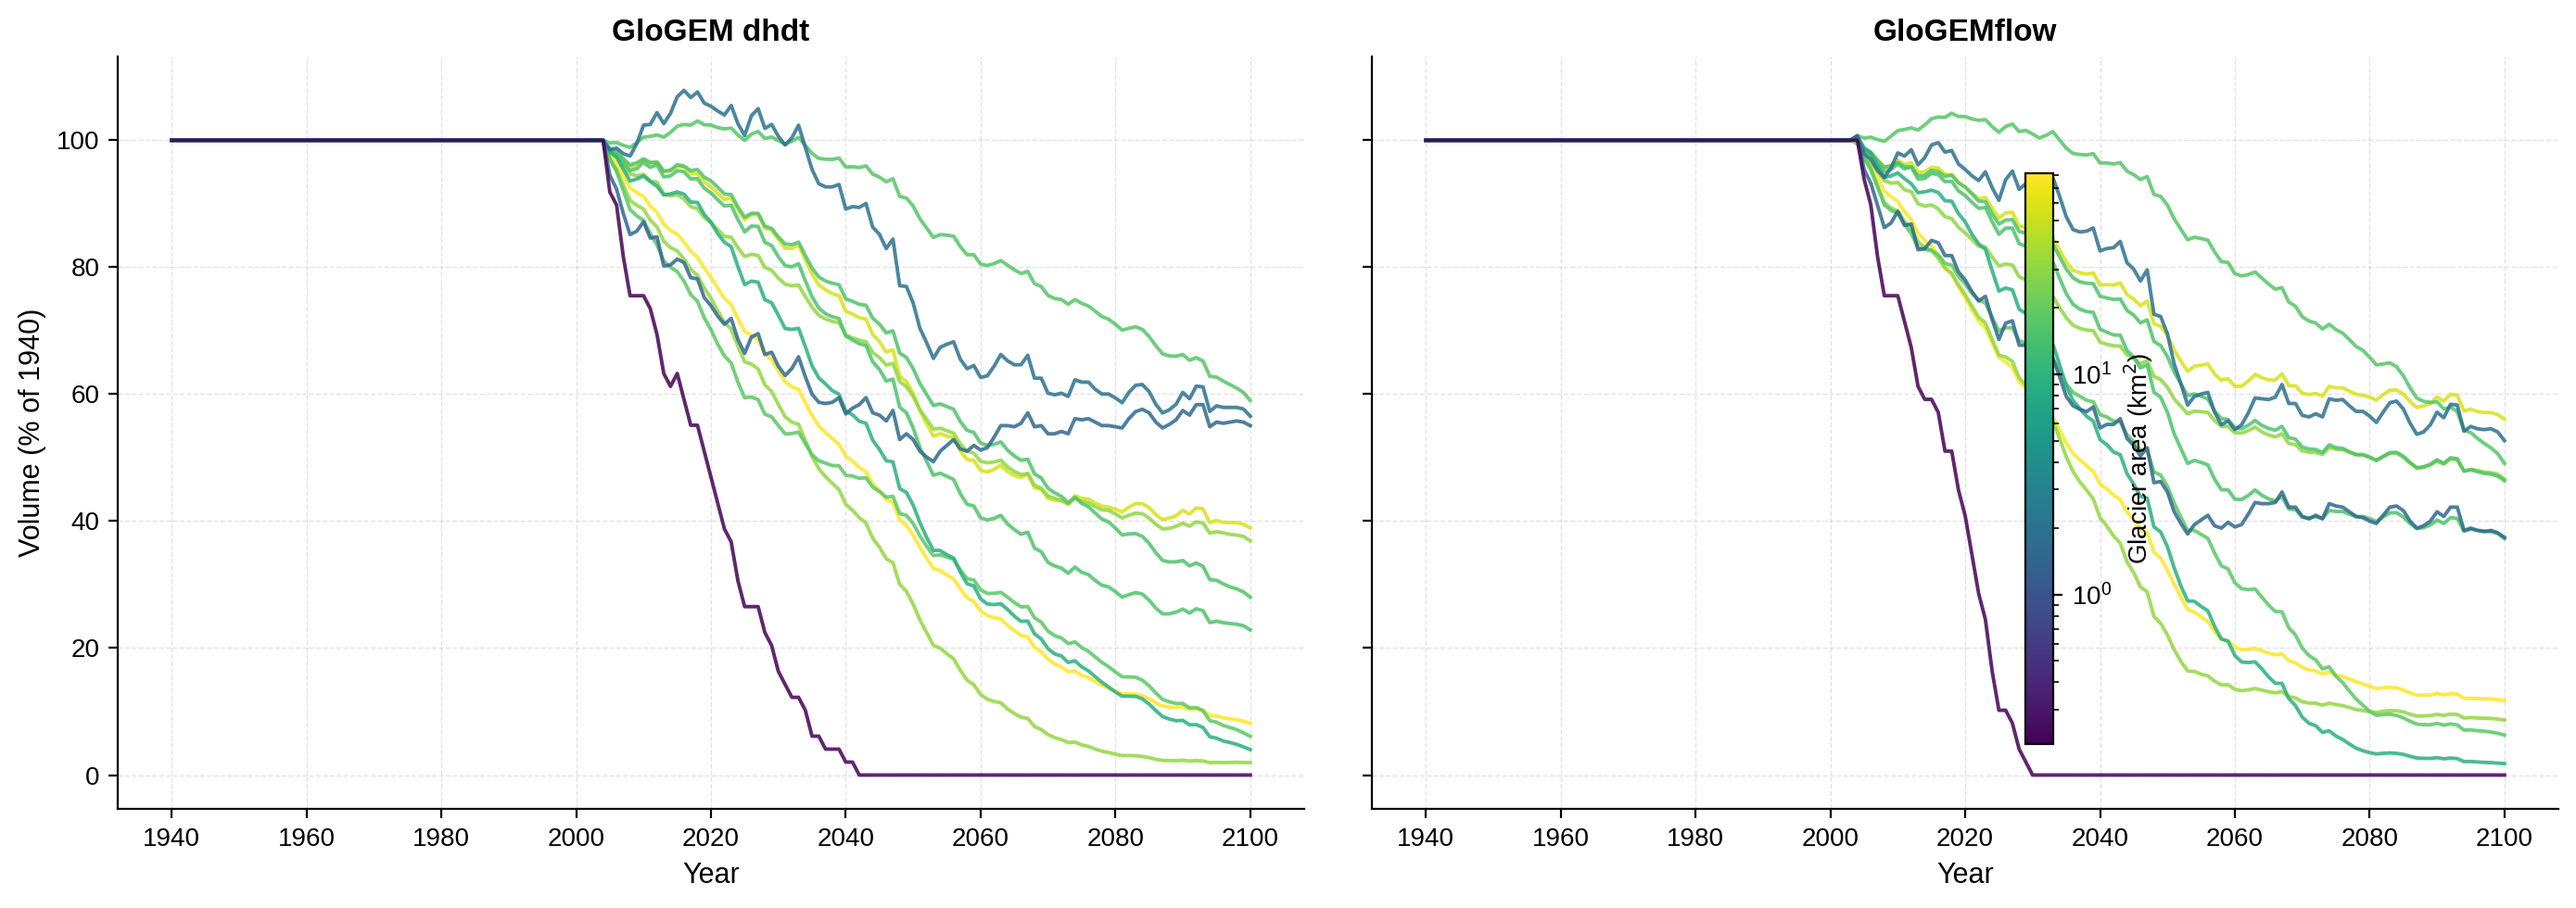

In [5]:
norm = mcolors.LogNorm(vmin=GLACIER_AREAS.min(), vmax=GLACIER_AREAS.max())
cmap = plt.cm.viridis

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
titles = ['GloGEM dhdt', 'GloGEMflow']
data_vols = [vol_dhdt, vol_flow]

for ax, title, vol in zip(axes, titles, data_vols):
    for g in range(N_GL):
        v0 = vol[g, 0]
        if v0 > 0:
            ax.plot(years, vol[g] / v0 * 100,
                    color=cmap(norm(GLACIER_AREAS[g])), lw=1.4, alpha=0.85)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Year')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

axes[0].set_ylabel('Volume (% of 1940)')

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, shrink=0.8, pad=0.02)
cbar.set_label('Glacier area (km$^2$)', fontsize=10)

fig.tight_layout()
plt.show()

## 3. Per-glacier area + volume panels

Each panel: area (dashed) and volume (solid), both normalised to 1940 value.  
Blue = GloGEM dhdt, orange = GloGEMflow.

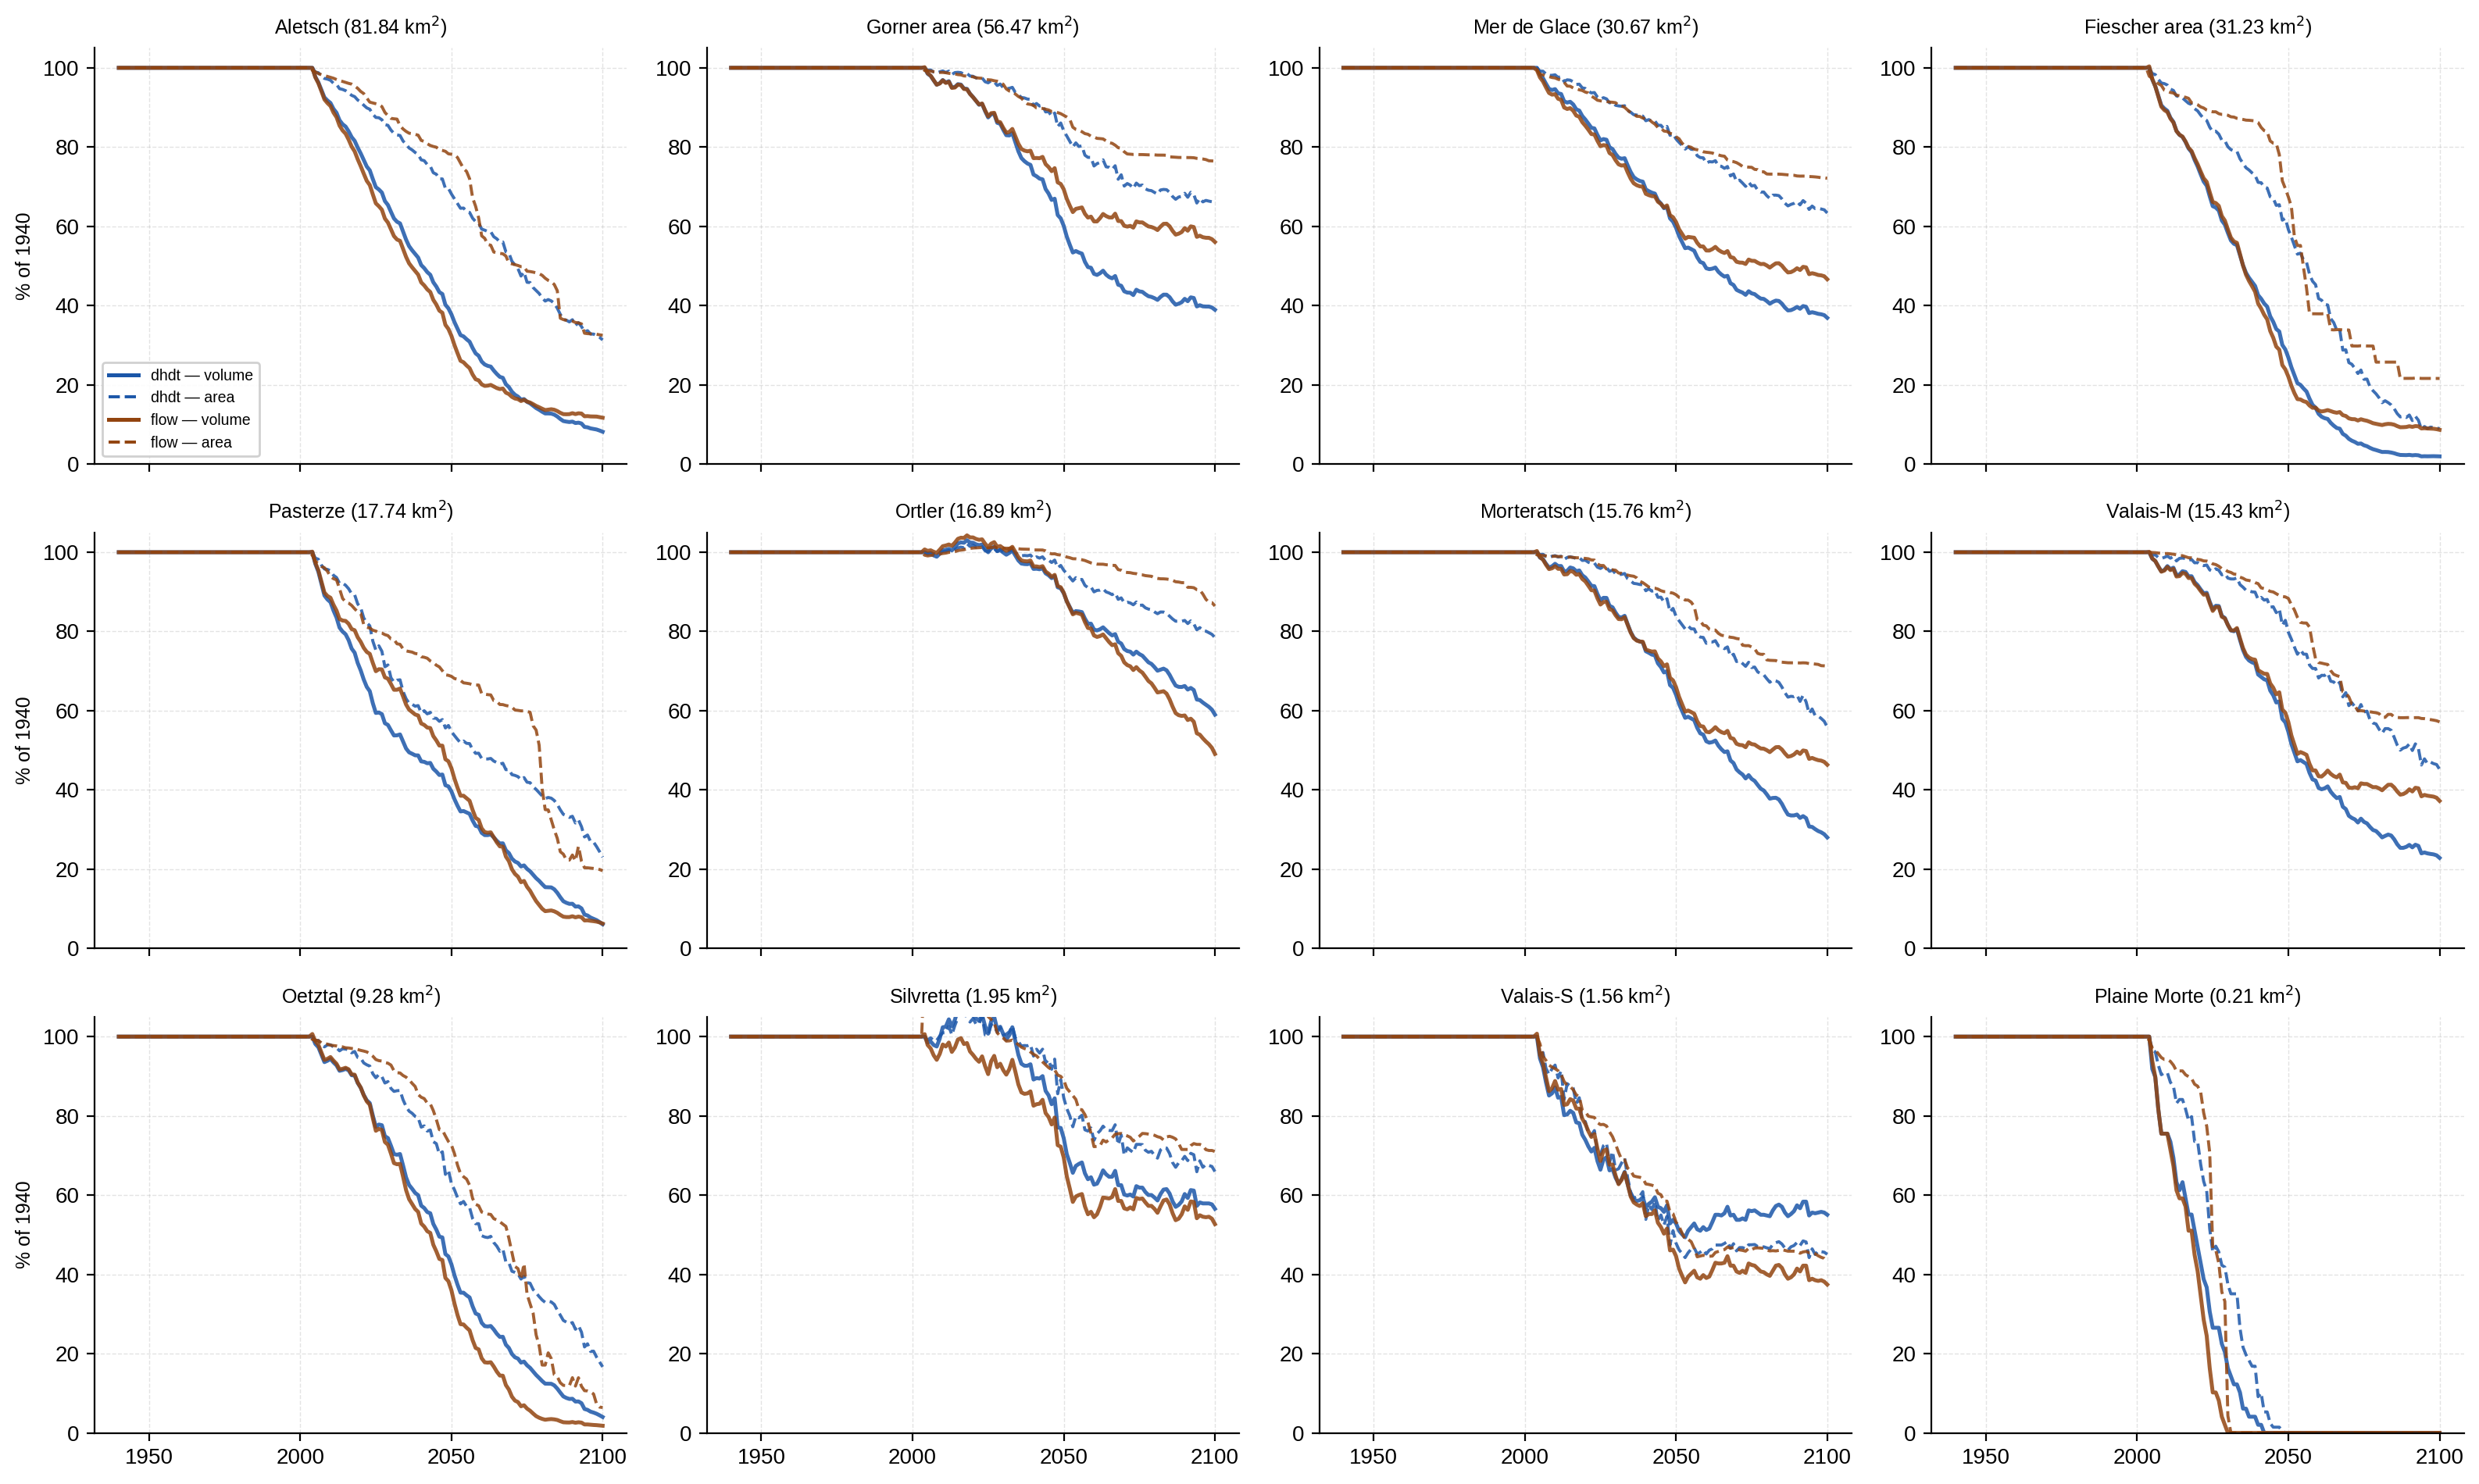

In [6]:
from matplotlib.lines import Line2D

NCOLS = 4
NROWS = (N_GL + NCOLS - 1) // NCOLS
fig, axes = plt.subplots(NROWS, NCOLS, figsize=(16, NROWS * 3.2), sharex=True)
axes = axes.flatten()

legend_elements = [
    Line2D([0], [0], color=COL_DHDT, lw=1.8,             label='dhdt — volume'),
    Line2D([0], [0], color=COL_DHDT, lw=1.4, ls='--',    label='dhdt — area'),
    Line2D([0], [0], color=COL_FLOW,  lw=1.8,             label='flow — volume'),
    Line2D([0], [0], color=COL_FLOW,  lw=1.4, ls='--',    label='flow — area'),
]

for g in range(N_GL):
    ax = axes[g]
    a0_d = area_dhdt[g, 0] if area_dhdt[g, 0] > 0 else 1.0
    v0_d = vol_dhdt[g, 0]  if vol_dhdt[g, 0]  > 0 else 1.0
    a0_f = area_flow[g, 0] if area_flow[g, 0] > 0 else 1.0
    v0_f = vol_flow[g, 0]  if vol_flow[g, 0]  > 0 else 1.0

    ax.plot(years, area_dhdt[g] / a0_d * 100, color=COL_DHDT, lw=1.4, ls='--', alpha=0.85)
    ax.plot(years, vol_dhdt[g]  / v0_d * 100, color=COL_DHDT, lw=1.8,          alpha=0.85)
    ax.plot(years, area_flow[g] / a0_f * 100, color=COL_FLOW,  lw=1.4, ls='--', alpha=0.85)
    ax.plot(years, vol_flow[g]  / v0_f * 100, color=COL_FLOW,  lw=1.8,          alpha=0.85)

    ax.set_title(f'{GLACIER_NAMES[g]} ({GLACIER_AREAS[g]:.2f} km$^2$)', fontsize=9)
    ax.set_ylim(0, 105)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=4))
    if g % NCOLS == 0:
        ax.set_ylabel('% of 1940', fontsize=9)
    if g == 0:
        ax.legend(handles=legend_elements, fontsize=7, loc='lower left')

for ax in axes[N_GL:]:
    ax.set_visible(False)

fig.tight_layout()
plt.show()

## 4. 2100 volume-loss summary

Grouped bars: remaining volume at 2100 as % of 1940 value.  
Glaciers sorted by area (largest left).

Glacier          Area (km2)  dhdt V%  flow V%
------------------------------------------------
Aletsch               81.84      8.2     11.7
Gorner area           56.47     38.9     56.0
Fiescher area         31.23      2.0      8.7
Mer de Glace          30.67     36.9     46.6
Pasterze              17.74      6.1      6.3
Ortler                16.89     59.0     49.1
Morteratsch           15.76     28.0     46.4
Valais-M              15.43     22.9     37.2
Oetztal                9.28      4.0      1.8
Silvretta              1.95     56.5     52.7
Valais-S               1.56     55.0     37.4
Plaine Morte           0.21      0.0      0.0


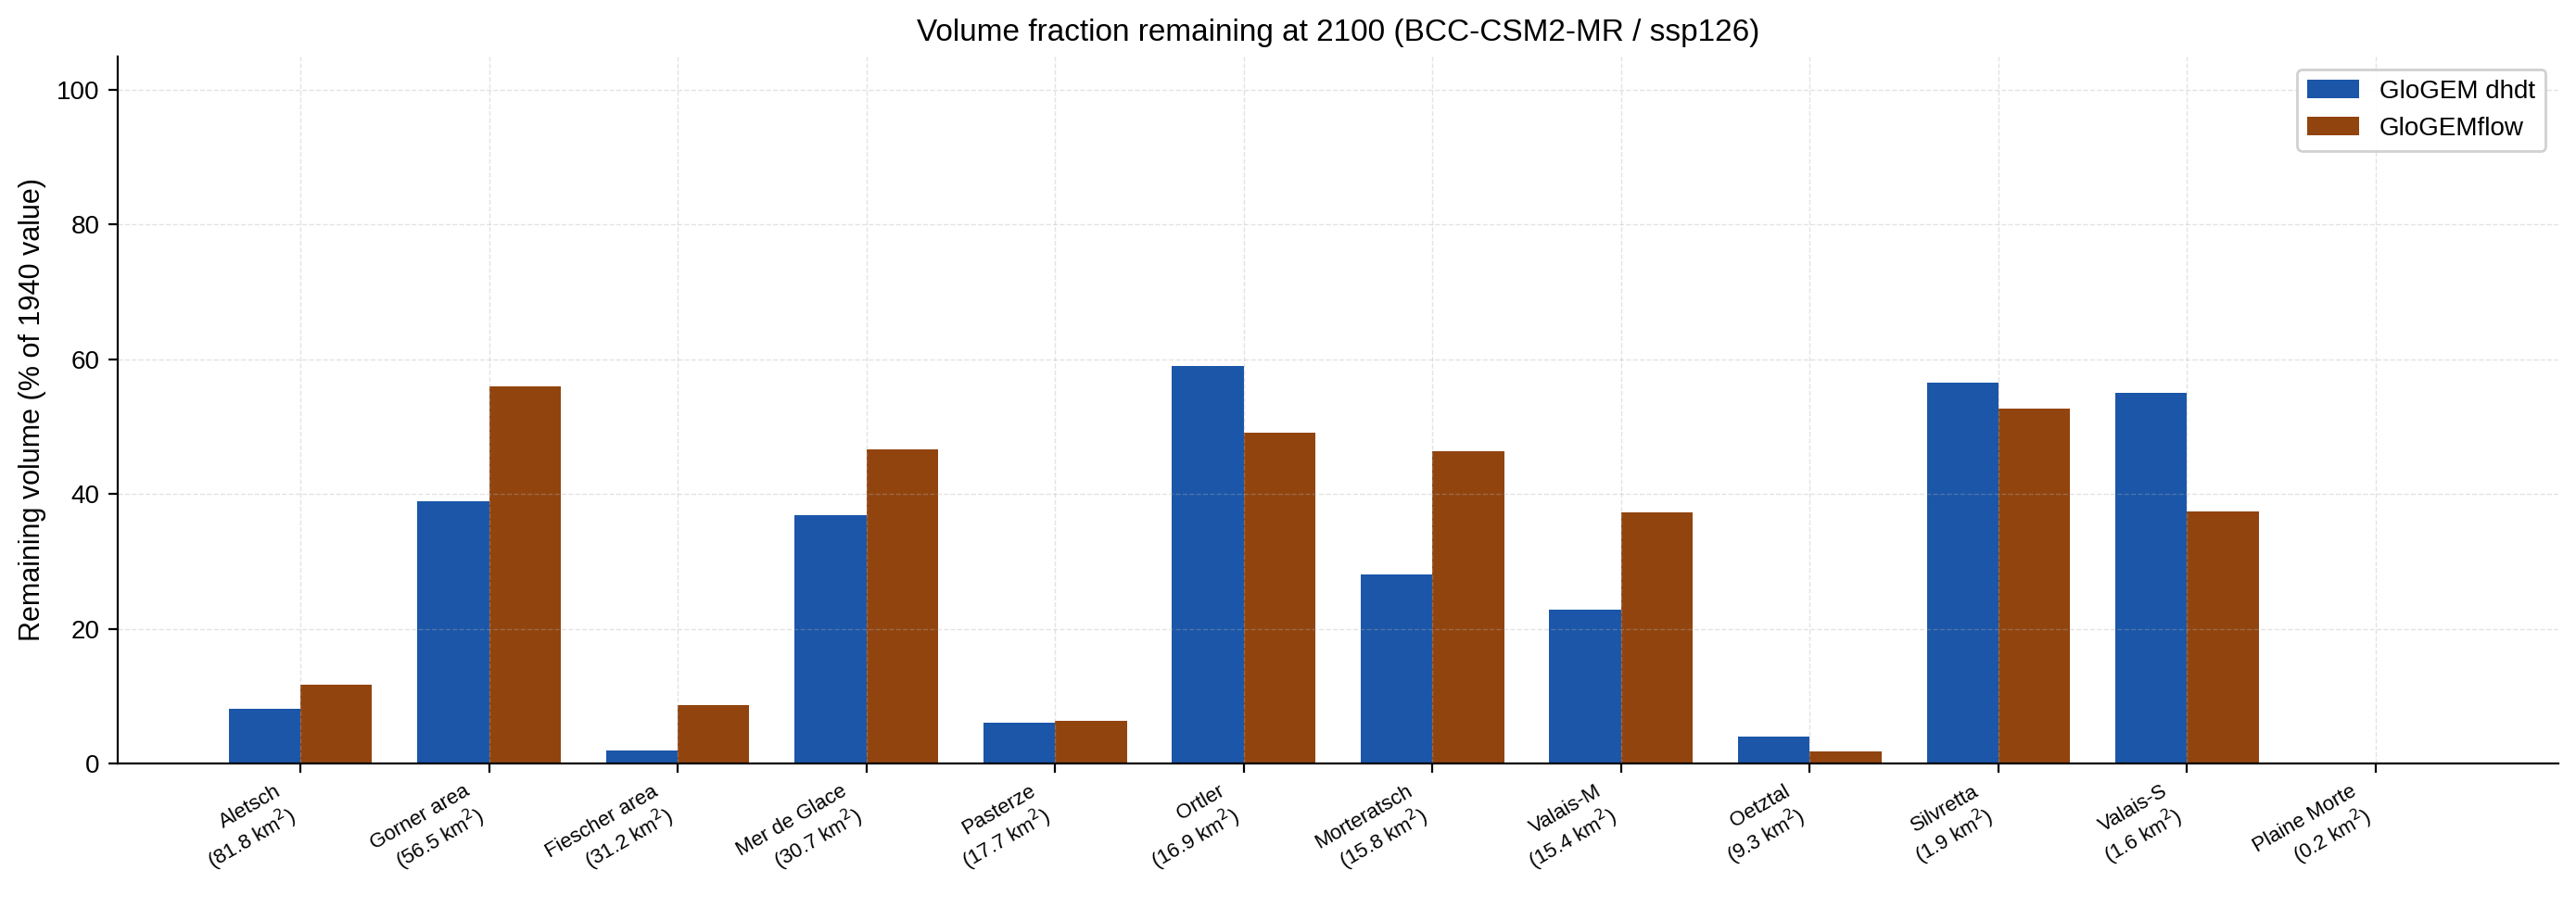

In [7]:
i_yr0  = 0
i_2100 = 2100 - TRAN0

sort_idx      = np.argsort(GLACIER_AREAS)[::-1]
names_sorted  = [GLACIER_NAMES[i] for i in sort_idx]
areas_sorted  = GLACIER_AREAS[sort_idx]

vfrac_dhdt = np.array([
    vol_dhdt[i, i_2100] / vol_dhdt[i, i_yr0] * 100 if vol_dhdt[i, i_yr0] > 0 else 0
    for i in sort_idx
])
vfrac_flow  = np.array([
    vol_flow[i,  i_2100] / vol_flow[i,  i_yr0] * 100 if vol_flow[i,  i_yr0] > 0 else 0
    for i in sort_idx
])

print(f"{'Glacier':<16} {'Area (km2)':>10} {'dhdt V%':>8} {'flow V%':>8}")
print('-' * 48)
for name, area, vd, vf in zip(names_sorted, areas_sorted, vfrac_dhdt, vfrac_flow):
    print(f'{name:<16} {area:>10.2f} {vd:>8.1f} {vf:>8.1f}')

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(N_GL, dtype=float)
w = 0.38
ax.bar(x - w/2, vfrac_dhdt, w, color=COL_DHDT, label='GloGEM dhdt')
ax.bar(x + w/2, vfrac_flow,  w, color=COL_FLOW,  label='GloGEMflow')
ax.set_xticks(x)
ax.set_xticklabels(
    [f'{n}\n({a:.1f} km$^2$)' for n, a in zip(names_sorted, areas_sorted)],
    fontsize=8, rotation=30, ha='right'
)
ax.set_ylabel('Remaining volume (% of 1940 value)')
ax.set_title('Volume fraction remaining at 2100 (BCC-CSM2-MR / ssp126)', fontsize=12)
ax.set_ylim(0, 105)
ax.legend(loc='upper right', fontsize=10)
fig.tight_layout()
plt.show()

## 5. MB bias table (Hugonnet 2000–2019 period)

Mean annual MB in m w.e. yr⁻¹ for both models vs Hugonnet geodetic observations.

In [8]:
print(f"{'Glacier':<16} {'Area':>7} {'Hugonnet':>10} {'dhdt':>8} {'flow':>8} {'bias_d':>8} {'bias_f':>8}")
print('-' * 72)
for g in range(N_GL):
    m_d = mb_dhdt[g, i_hug0:i_hug1].mean()
    m_f = mb_flow[g,  i_hug0:i_hug1].mean()
    print(
        f'{GLACIER_NAMES[g]:<16} {GLACIER_AREAS[g]:>7.2f}'
        f' {hug_mb[g]:>10.3f} {m_d:>8.3f} {m_f:>8.3f}'
        f' {m_d - hug_mb[g]:>+8.3f} {m_f - hug_mb[g]:>+8.3f}'
    )
print('\nAll values in m w.e. yr-1')

Glacier             Area   Hugonnet     dhdt     flow   bias_d   bias_f
------------------------------------------------------------------------
Aletsch            81.84     -1.216   -1.740   -1.877   -0.524   -0.661
Gorner area        56.47     -0.821   -0.251   -0.265   +0.570   +0.556
Mer de Glace       30.67     -1.053   -0.621   -0.696   +0.432   +0.357
Fiescher area      31.23     -1.065   -1.549   -1.490   -0.484   -0.425
Pasterze           17.74     -1.321   -1.236   -0.989   +0.085   +0.332
Ortler             16.89     -0.706    0.213    0.257   +0.919   +0.963
Morteratsch        15.76     -1.022   -0.192   -0.231   +0.830   +0.791
Valais-M           15.43     -0.908   -0.247   -0.251   +0.661   +0.657
Oetztal             9.28     -0.950   -0.413   -0.438   +0.537   +0.512
Silvretta           1.95     -0.751    0.221   -0.272   +0.972   +0.479
Valais-S            1.56     -0.712   -0.500   -0.461   +0.212   +0.251
Plaine Morte        0.21     -0.767   -0.679   -0.707   +0.088 